# Stage 4 — Exploratory Data Analysis

EDA examines the target distribution, availability, missingness, exploratory correlations, outliers, and a descriptive COVID-period timeline. These analyses help understand the data before final model training.

## 4.1 U5MR availability over time

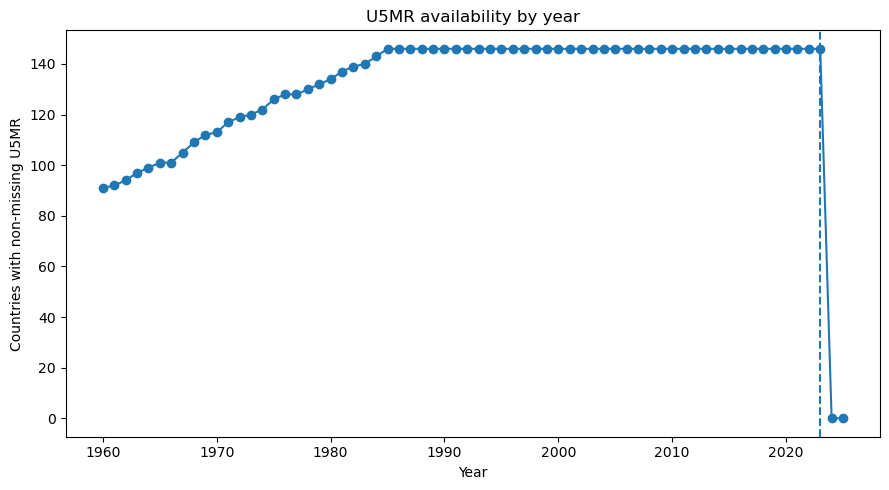

In [312]:
plt.figure(figsize=(9, 5))
plt.plot(u5mr_availability["year"], u5mr_availability["available_countries"], marker="o")
plt.axvline(TARGET_YEAR, linestyle="--")
plt.title("U5MR availability by year")
plt.xlabel("Year")
plt.ylabel("Countries with non-missing U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_availability_by_year.png", dpi=300)
plt.show()

## 4.2 Target distribution: U5MR 2023

count    146.000000
mean      24.534932
std       23.904348
min        2.100000
25%        6.275000
50%       15.350000
75%       38.000000
max      114.800000
Name: u5mr_2023, dtype: float64

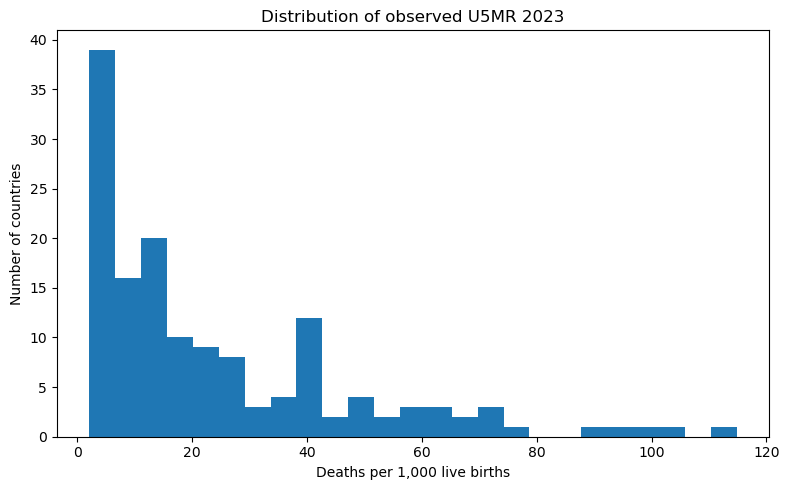

In [314]:
display(target_df["u5mr_2023"].describe())

plt.figure(figsize=(8, 5))
plt.hist(target_df["u5mr_2023"], bins=25)
plt.title("Distribution of observed U5MR 2023")
plt.xlabel("Deaths per 1,000 live births")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(VIS_DIR / "target_u5mr_2023_distribution.png", dpi=300)
plt.show()

## 4.3 Log target distribution

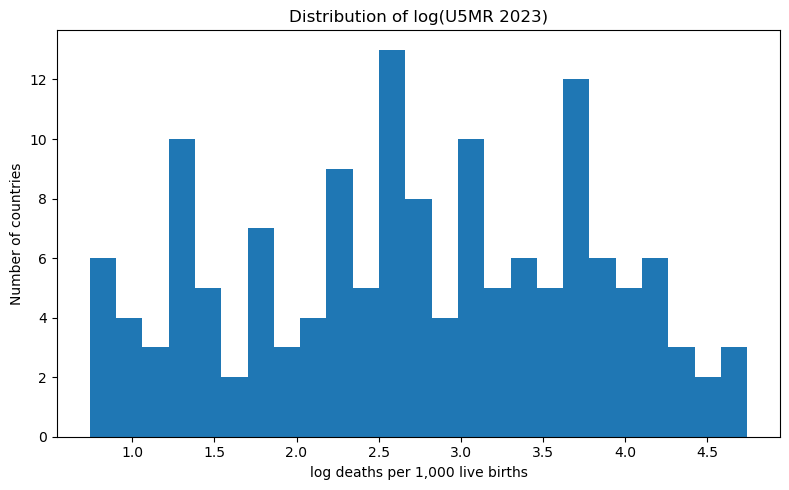

In [316]:
plt.figure(figsize=(8, 5))
plt.hist(target_df["log_u5mr_2023"], bins=25)
plt.title("Distribution of log(U5MR 2023)")
plt.xlabel("log deaths per 1,000 live births")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(VIS_DIR / "target_log_u5mr_2023_distribution.png", dpi=300)
plt.show()

## 4.4 Highest and lowest U5MR countries

In [318]:
print("Highest U5MR countries")
display(target_df.sort_values("u5mr_2023", ascending=False).head(15))

print("Lowest U5MR countries")
display(target_df.sort_values("u5mr_2023", ascending=True).head(15))

Highest U5MR countries


,country_code,country_name,u5mr_2023,log_u5mr_2023
1,NER,Niger,114.8,4.743191
124,SOM,"Somalia, Federal Republic of",104.0,4.644391
2,SSD,South Sudan,98.7,4.592085
80,GIN,Guinea,95.0,4.553877
107,MLI,Mali,91.3,4.514151
73,BEN,Benin,77.9,4.355426
78,COD,"Congo, Dem. Rep.",73.2,4.293195
96,LBR,Liberia,72.9,4.289089
11,GNQ,Equatorial Guinea,70.6,4.257030
28,GNB,Guinea-Bissau,69.3,4.238445


Lowest U5MR countries


,country_code,country_name,u5mr_2023,log_u5mr_2023
70,SGP,Singapore,2.1,0.741937
94,EST,Estonia,2.1,0.741937
66,SVN,Slovenia,2.2,0.788457
128,LUX,Luxembourg,2.3,0.832909
93,BLR,Belarus,2.4,0.875469
109,JPN,Japan,2.4,0.875469
140,SWE,Sweden,2.5,0.916291
24,MNE,Montenegro,2.6,0.955511
88,ISL,Iceland,2.6,0.955511
114,KOR,"Korea, Rep.",2.8,1.029619


## 4.5 Helper functions for 2022 values and 5-year changes

In [320]:
def most_recent_pre_target_values(wide_df, years, value_name="most_recent_value"):
    selected_year_cols = [str(y) for y in years]
    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"]).sort_values(["country_code", "indicator_code", "source_year"])
    most_recent_df = long_df.groupby(["country_code", "country_name", "indicator_code", "indicator_name"], as_index=False).tail(1)
    most_recent_df = most_recent_df.rename(columns={"value": value_name})
    return most_recent_df


def fixed_year_values(wide_df, year, value_name=None):
    year_col = str(year)
    if year_col not in wide_df.columns:
        raise ValueError(f"Year column {year_col} is not available.")
    if value_name is None:
        value_name = f"value_{year}"

    output = wide_df[["country_code", "country_name", "indicator_code", "indicator_name", year_col]].copy()
    output = output.rename(columns={year_col: value_name})
    output["source_year"] = int(year)
    output = output.dropna(subset=[value_name])
    return output


def five_year_change_values(wide_df, years):
    selected_year_cols = [str(y) for y in years]
    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"]).sort_values(["country_code", "indicator_code", "source_year"])

    first_df = long_df.groupby(["country_code", "indicator_code"], as_index=False).first()[
        ["country_code", "indicator_code", "source_year", "value"]
    ].rename(columns={"source_year": "change_start_year", "value": "change_start_value"})

    last_df = long_df.groupby(["country_code", "indicator_code"], as_index=False).last()[
        ["country_code", "indicator_code", "source_year", "value"]
    ].rename(columns={"source_year": "change_end_year", "value": "change_end_value"})

    meta = long_df[["country_code", "country_name", "indicator_code", "indicator_name"]].drop_duplicates(
        subset=["country_code", "indicator_code"]
    )

    change_df = first_df.merge(last_df, on=["country_code", "indicator_code"], how="inner")
    change_df = change_df.merge(meta, on=["country_code", "indicator_code"], how="left")
    change_df["change5y_value"] = change_df["change_end_value"] - change_df["change_start_value"]
    return change_df


def exact_change_between_years(wide_df, start_year, end_year):
    start_col = str(start_year)
    end_col = str(end_year)
    for col in [start_col, end_col]:
        if col not in wide_df.columns:
            raise ValueError(f"Year column {col} is not available.")

    output = wide_df[["country_code", "country_name", "indicator_code", "indicator_name", start_col, end_col]].copy()
    output = output.rename(columns={
        start_col: "change_start_value",
        end_col: "change_end_value"
    })
    output["change_start_year"] = int(start_year)
    output["change_end_year"] = int(end_year)
    output[f"change_{start_year}_{end_year}"] = output["change_end_value"] - output["change_start_value"]
    output = output.dropna(subset=[f"change_{start_year}_{end_year}"])
    return output


def mean_between_years(wide_df, start_year, end_year):
    selected_year_cols = [str(y) for y in range(start_year, end_year + 1)]
    for col in selected_year_cols:
        if col not in wide_df.columns:
            raise ValueError(f"Year column {col} is not available.")

    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"])

    mean_df = (
        long_df
        .groupby(["country_code", "country_name", "indicator_code", "indicator_name"], as_index=False)
        .agg(
            mean_value=("value", "mean"),
            observed_years=("value", "count"),
            mean_start_year=("source_year", "min"),
            mean_end_year=("source_year", "max")
        )
    )

    mean_df = mean_df.rename(columns={"mean_value": f"mean_{start_year}_{end_year}"})
    return mean_df

## 4.6 Most recent pre-2023 values for EDA

In [322]:
most_recent_pre2023_eda = most_recent_pre_target_values(country_wdi, PREDICTOR_YEARS)
most_recent_pre2023_eda = most_recent_pre2023_eda[most_recent_pre2023_eda["country_code"].isin(target_df["country_code"])].copy()

print("Most recent pre-2023 country-indicator observations:", most_recent_pre2023_eda.shape)

Most recent pre-2023 country-indicator observations: (127710, 6)


## 4.7 Indicator missingness landscape

,indicator_code,indicator_name,observed_countries,median_source_year,missing_countries,missing_pct
964,WB_WDI_SH_DYN_MORT,"Mortality rate, under-5 (per 1,000 live births)",146,2022.0,0,0.000000
669,WB_WDI_NY_GDP_MKTP_CN,GDP (current LCU),120,2022.0,26,0.178082
1332,WB_WDI_SP_POP_65UP_MA_IN,"Population ages 65 and above, male",120,2022.0,26,0.178082
1276,WB_WDI_SP_DYN_IMRT_FE_IN,"Mortality rate, infant, female (per 1,000 live...",118,2022.0,28,0.191781
212,WB_WDI_EG_ELC_FOSL_ZS,"Electricity production from oil, gas and coal ...",118,2022.0,28,0.191781
77,WB_WDI_CC_PER_RNK,Control of Corruption: Percentile Rank,118,2022.0,28,0.191781
965,WB_WDI_SH_DYN_MORT_FE,"Mortality rate, under-5, female (per 1,000 liv...",118,2022.0,28,0.191781
960,WB_WDI_SH_DYN_1519,Probability of dying among adolescents ages 15...,117,2022.0,29,0.198630
633,WB_WDI_NY_ADJ_DKAP_GN_ZS,Adjusted savings: consumption of fixed capital...,117,2021.0,29,0.198630
25,WB_WDI_AG_SRF_TOTL_K2,Surface area (sq. km),117,2022.0,29,0.198630


count    1466.000000
mean        0.403325
std         0.156250
min         0.000000
25%         0.294521
50%         0.356164
75%         0.458904
max         0.993151
Name: missing_pct, dtype: float64

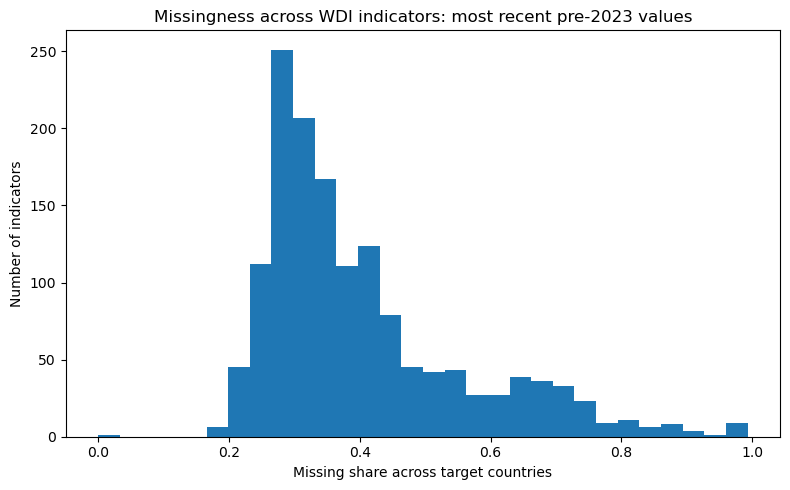

In [324]:
target_country_count = target_df["country_code"].nunique()

indicator_missingness = (
    most_recent_pre2023_eda
    .groupby(["indicator_code", "indicator_name"], as_index=False)
    .agg(
        observed_countries=("most_recent_value", "count"),
        median_source_year=("source_year", "median")
    )
)

indicator_missingness["missing_countries"] = target_country_count - indicator_missingness["observed_countries"]
indicator_missingness["missing_pct"] = indicator_missingness["missing_countries"] / target_country_count
indicator_missingness = indicator_missingness.sort_values("missing_pct")

indicator_missingness.to_csv(TABLE_DIR / "indicator_missingness_pre2023.csv", index=False)

display(indicator_missingness.head(10))

display(indicator_missingness["missing_pct"].describe())

plt.figure(figsize=(8, 5))
plt.hist(indicator_missingness["missing_pct"], bins=30)
plt.title("Missingness across WDI indicators: most recent pre-2023 values")
plt.xlabel("Missing share across target countries")
plt.ylabel("Number of indicators")
plt.tight_layout()
plt.savefig(VIS_DIR / "indicator_missingness_distribution.png", dpi=300)
plt.show()

## 4.8 Exploratory correlations with log U5MR

In [326]:
merged_for_eda_corr = most_recent_pre2023_eda.merge(
    target_df[["country_code", "log_u5mr_2023"]],
    on="country_code",
    how="inner"
)

corr_rows = []
for (code_value, name_value), group in merged_for_eda_corr.groupby(["indicator_code", "indicator_name"]):
    valid = group[["most_recent_value", "log_u5mr_2023"]].dropna()
    if len(valid) >= 50 and valid["most_recent_value"].nunique() > 1:
        corr_value = valid["most_recent_value"].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan
    corr_rows.append({
        "indicator_code": code_value,
        "indicator_name": name_value,
        "eda_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "valid_pairs": len(valid)
    })

eda_correlations = pd.DataFrame(corr_rows).merge(
    indicator_missingness[["indicator_code", "missing_pct"]],
    on="indicator_code",
    how="left"
)

eda_correlations.to_csv(TABLE_DIR / "eda_spearman_correlations_pre2023.csv", index=False)

print("Strongest negative correlations")
display(eda_correlations.dropna().sort_values("eda_spearman_corr").head(12)[
    ["indicator_name", "missing_pct", "eda_spearman_corr", "valid_pairs"]
])

print("Strongest positive correlations")
display(eda_correlations.dropna().sort_values("eda_spearman_corr", ascending=False).head(12)[
    ["indicator_name", "missing_pct", "eda_spearman_corr", "valid_pairs"]
])

Strongest negative correlations


,indicator_name,missing_pct,eda_spearman_corr,valid_pairs
1279,"Life expectancy at birth, female (years)",0.205479,-0.923952,116
1002,Lifetime risk of maternal death (1 in: rate va...,0.280822,-0.919699,105
1283,"Survival to age 65, female (% of cohort)",0.226027,-0.908614,113
505,Fixed broadband subscriptions (per 100 people),0.294521,-0.906001,103
405,Human capital index plus (HCI+): education pil...,0.397260,-0.905131,88
410,Human capital index plus (HCI+): health pillar...,0.390411,-0.902504,89
1355,"Completeness of birth registration, male (%)",0.390411,-0.897141,89
408,Human capital index plus (HCI+): health pillar...,0.267123,-0.896682,107
1354,"Completeness of birth registration, female (%)",0.417808,-0.895818,85
1280,"Life expectancy at birth, total (years)",0.260274,-0.894500,108


Strongest positive correlations


,indicator_name,missing_pct,eda_spearman_corr,valid_pairs
1277,"Mortality rate, infant (per 1,000 live births)",0.260274,0.993133,108
964,"Mortality rate, under-5 (per 1,000 live births)",0.000000,0.992924,146
965,"Mortality rate, under-5, female (per 1,000 liv...",0.191781,0.991755,118
966,"Mortality rate, under-5, male (per 1,000 live ...",0.273973,0.990613,106
1276,"Mortality rate, infant, female (per 1,000 live...",0.191781,0.987189,118
1278,"Mortality rate, infant, male (per 1,000 live b...",0.253425,0.984864,109
970,"Mortality rate, neonatal (per 1,000 live births)",0.267123,0.977640,107
959,Probability of dying among adolescents ages 10...,0.219178,0.934353,114
958,Probability of dying among children ages 5-9 y...,0.246575,0.932818,110
1003,Lifetime risk of maternal death (%),0.321918,0.916800,99


## 4.9 U5MR outlier inspection

In [328]:
q1 = target_df["u5mr_2023"].quantile(0.25)
q3 = target_df["u5mr_2023"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outliers = target_df[target_df["u5mr_2023"] > upper_fence].sort_values("u5mr_2023", ascending=False)

print("IQR upper fence:", round(upper_fence, 2))
print("Countries flagged as high-U5MR outliers:", len(outliers))
display(outliers)

outliers.to_csv(TABLE_DIR / "u5mr_2023_high_outliers_iqr.csv", index=False)

IQR upper fence: 85.59
Countries flagged as high-U5MR outliers: 5


,country_code,country_name,u5mr_2023,log_u5mr_2023
1,NER,Niger,114.8,4.743191
124,SOM,"Somalia, Federal Republic of",104.0,4.644391
2,SSD,South Sudan,98.7,4.592085
80,GIN,Guinea,95.0,4.553877
107,MLI,Mali,91.3,4.514151


## 4.10 Example scatter plots

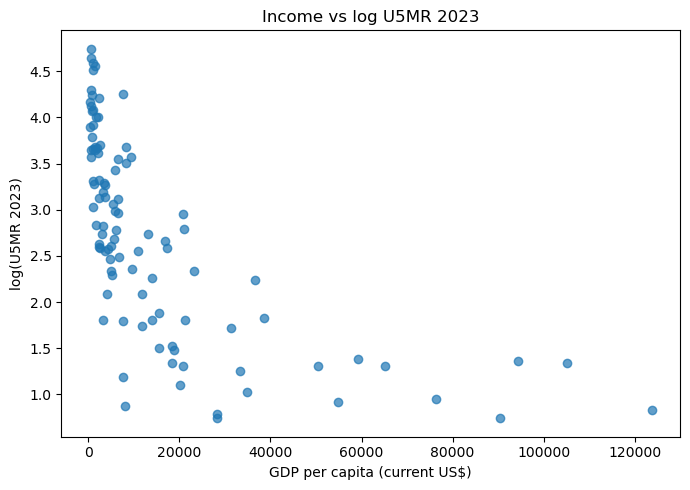

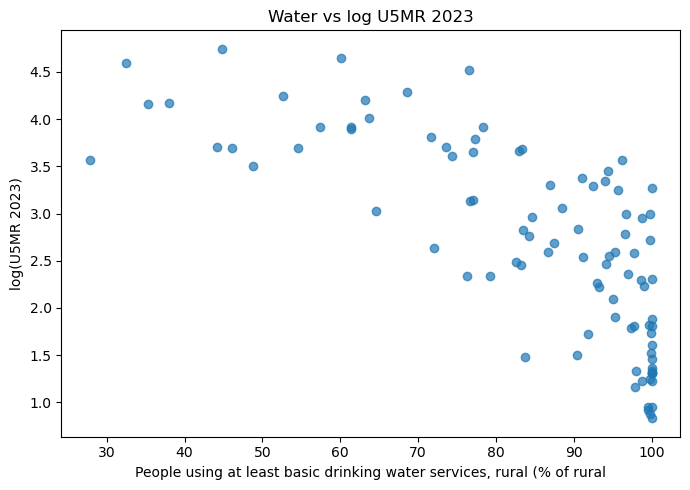

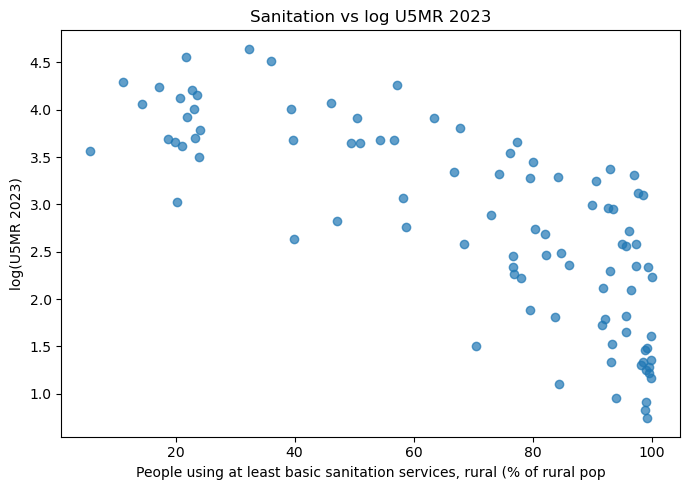

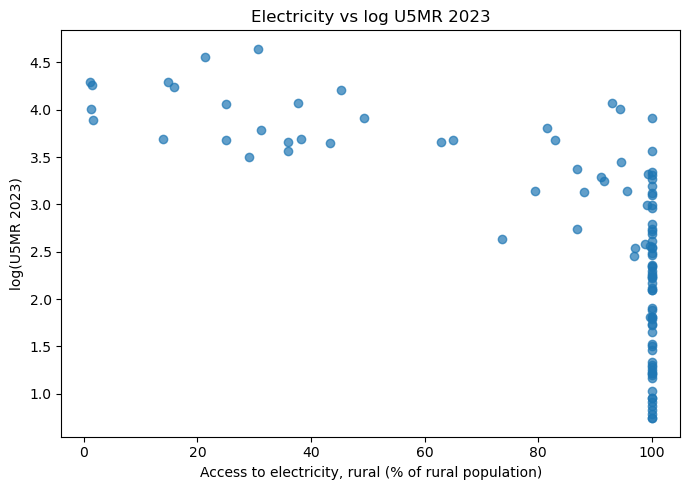

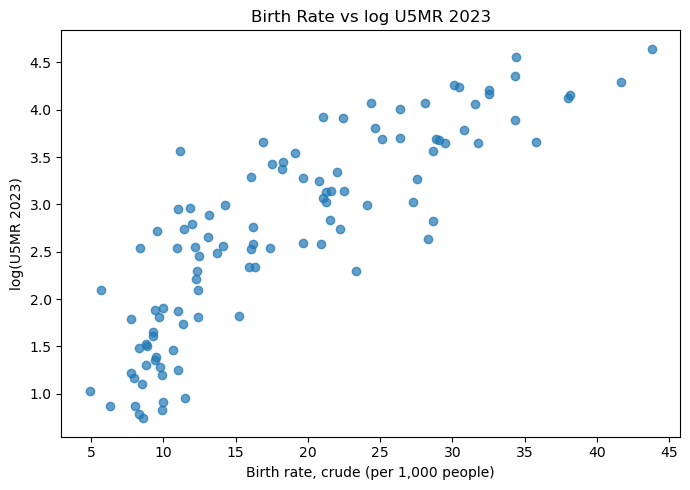

In [330]:
def find_indicator_by_keywords(indicator_table, keyword_options):
    names = indicator_table[["indicator_code", "indicator_name"]].drop_duplicates().copy()
    names["name_lower"] = names["indicator_name"].str.lower()
    for keywords in keyword_options:
        keywords = [kw.lower() for kw in keywords]
        mask = names["name_lower"].apply(lambda value: all(kw in value for kw in keywords))
        matches = names[mask]
        if len(matches) > 0:
            return matches.iloc[0]["indicator_code"], matches.iloc[0]["indicator_name"]
    return None, None

scatter_specs = {
    "income": [["gdp per capita"], ["gni per capita"], ["income per capita", "bottom 40"]],
    "water": [["basic drinking water", "population"]],
    "sanitation": [["basic sanitation", "population"]],
    "electricity": [["access to electricity"]],
    "birth_rate": [["birth rate", "crude"]]
}

for short_name, keyword_options in scatter_specs.items():
    code_value, name_value = find_indicator_by_keywords(indicator_inventory, keyword_options)
    if code_value is None:
        print(f"No matching indicator found for {short_name}.")
        continue

    plot_df = most_recent_pre2023_eda[most_recent_pre2023_eda["indicator_code"] == code_value].merge(
        target_df[["country_code", "log_u5mr_2023"]],
        on="country_code",
        how="inner"
    ).dropna(subset=["most_recent_value", "log_u5mr_2023"])

    if len(plot_df) < 30:
        continue

    plt.figure(figsize=(7, 5))
    plt.scatter(plot_df["most_recent_value"], plot_df["log_u5mr_2023"], alpha=0.7)
    plt.title(f"{short_name.replace('_', ' ').title()} vs log U5MR 2023")
    plt.xlabel(name_value[:70])
    plt.ylabel("log(U5MR 2023)")
    plt.tight_layout()
    plt.savefig(VIS_DIR / f"scatter_{short_name}_log_u5mr.png", dpi=300)
    plt.show()

## 4.11 Descriptive COVID-period U5MR timeline

This is an exploratory timeline, not a causal COVID impact analysis. U5MR values in WDI often move gradually and may be estimate-based rather than direct annual counts. Therefore, this section asks a descriptive question only:

**Was the U5MR level during the COVID period visibly higher than the surrounding pre-COVID and post-COVID periods?**

Periods used here:

- **Pre-COVID:** 2015–2019
- **COVID period:** 2020–2021
- **Post-COVID / most recent observed period:** 2022–2023

,year,median_u5mr,mean_u5mr,countries
0,2015,18.65,31.191096,146
1,2016,17.95,30.509589,146
2,2017,17.20,30.026027,146
3,2018,16.60,28.145890,146
4,2019,16.65,27.180822,146
5,2020,15.90,26.347260,146
6,2021,15.15,25.638356,146
7,2022,14.70,25.206164,146
8,2023,15.35,24.534932,146


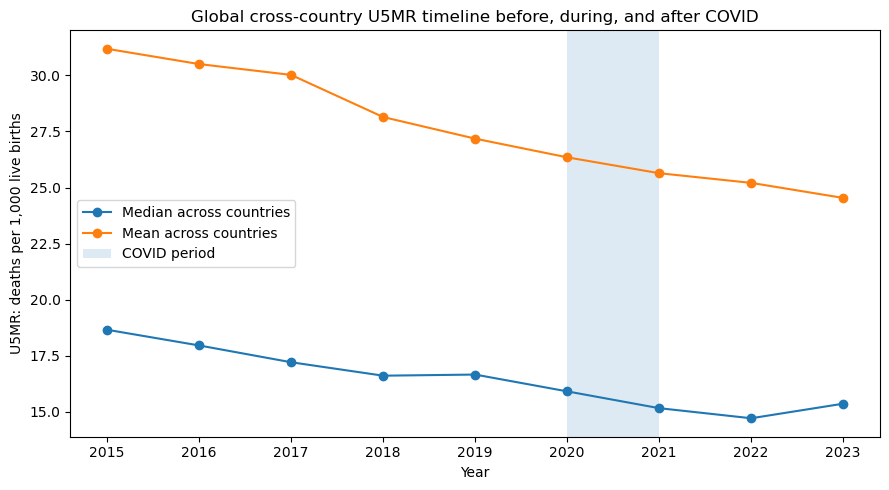

In [332]:
covid_years = list(range(2015, TARGET_YEAR + 1))
u5mr_timeline = u5mr_wide[["country_code", "country_name"] + [str(y) for y in covid_years]].melt(
    id_vars=["country_code", "country_name"],
    var_name="year",
    value_name="u5mr"
)
u5mr_timeline["year"] = u5mr_timeline["year"].astype(int)
u5mr_timeline = u5mr_timeline.dropna(subset=["u5mr"])

global_timeline = (
    u5mr_timeline
    .groupby("year", as_index=False)
    .agg(
        median_u5mr=("u5mr", "median"),
        mean_u5mr=("u5mr", "mean"),
        countries=("country_code", "nunique")
    )
)

global_timeline.to_csv(TABLE_DIR / "u5mr_covid_timeline_global.csv", index=False)
display(global_timeline)

plt.figure(figsize=(9, 5))
plt.plot(global_timeline["year"], global_timeline["median_u5mr"], marker="o", label="Median across countries")
plt.plot(global_timeline["year"], global_timeline["mean_u5mr"], marker="o", label="Mean across countries")
plt.axvspan(2020, 2021, alpha=0.15, label="COVID period")
plt.title("Global cross-country U5MR timeline before, during, and after COVID")
plt.xlabel("Year")
plt.ylabel("U5MR: deaths per 1,000 live births")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_timeline_before_during_after_covid.png", dpi=300)
plt.show()

## 4.12 Compare pre-COVID, COVID, and post-COVID country averages

,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
pre_covid_2015_2019,146.0,29.410685,31.170614,2.50,7.9700,17.290,45.3650,201.96
covid_2020_2021,146.0,25.992808,25.665058,2.25,6.6750,15.575,41.8125,119.85
post_covid_2022_2023,146.0,24.870548,24.699862,2.15,6.3500,15.500,38.7750,123.45
covid_minus_pre,146.0,-3.417877,8.984575,-103.26,-4.2500,-1.665,-0.3500,4.75
post_minus_covid,146.0,-1.122260,2.138401,-5.80,-2.0875,-0.750,-0.1500,10.80


C:\Users\ayoub\AppData\Local\Temp\ipykernel_29348\1975163887.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["Pre-COVID\n2015–2019", "COVID\n2020–2021", "Post-COVID\n2022–2023"])


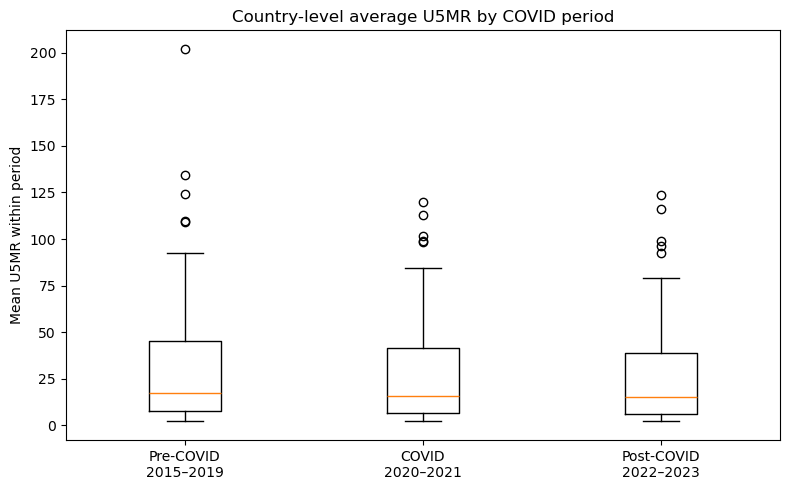

In [334]:
def assign_covid_period(year):
    if 2015 <= year <= 2019:
        return "pre_covid_2015_2019"
    if 2020 <= year <= 2021:
        return "covid_2020_2021"
    if 2022 <= year <= 2023:
        return "post_covid_2022_2023"
    return np.nan

period_df = u5mr_timeline.copy()
period_df["period"] = period_df["year"].apply(assign_covid_period)
period_df = period_df.dropna(subset=["period"])

country_period = (
    period_df
    .groupby(["country_code", "country_name", "period"], as_index=False)
    .agg(mean_u5mr=("u5mr", "mean"))
)

period_wide = country_period.pivot_table(
    index=["country_code", "country_name"],
    columns="period",
    values="mean_u5mr"
).reset_index()

period_columns = ["pre_covid_2015_2019", "covid_2020_2021", "post_covid_2022_2023"]
period_wide = period_wide.dropna(subset=period_columns)
period_wide["covid_minus_pre"] = period_wide["covid_2020_2021"] - period_wide["pre_covid_2015_2019"]
period_wide["post_minus_covid"] = period_wide["post_covid_2022_2023"] - period_wide["covid_2020_2021"]

period_summary = period_wide[period_columns + ["covid_minus_pre", "post_minus_covid"]].describe().T
period_summary.to_csv(TABLE_DIR / "u5mr_covid_period_comparison_summary.csv")
period_wide.to_csv(TABLE_DIR / "u5mr_covid_period_country_comparison.csv", index=False)

display(period_summary)

plot_period_long = period_wide.melt(
    id_vars=["country_code", "country_name"],
    value_vars=period_columns,
    var_name="period",
    value_name="mean_u5mr"
)

plt.figure(figsize=(8, 5))
plot_data = [plot_period_long.loc[plot_period_long["period"] == p, "mean_u5mr"] for p in period_columns]
plt.boxplot(plot_data, labels=["Pre-COVID\n2015–2019", "COVID\n2020–2021", "Post-COVID\n2022–2023"])
plt.title("Country-level average U5MR by COVID period")
plt.ylabel("Mean U5MR within period")
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_boxplot_covid_periods.png", dpi=300)
plt.show()

### COVID-period interpretation note

The COVID-period comparison is useful context for the project, but it should remain in EDA. It should not replace the main research question, which is cross-sectional prediction of U5MR 2023 from lagged WDI indicators.

The timeline should also be interpreted cautiously because WDI U5MR values are annual country-level estimates and may be smoothed over time. A gradual trend during 2020–2023 therefore does not prove that the pandemic had no effect on child mortality. The analysis is descriptive, not causal.